In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as plr
%matplotlib inline

In [9]:
N = 50

opinions = {
    i: {
        "politics": np.random.uniform(-1, 1),
        "environment": np.random.uniform(-1, 1)
    }
    for i in range(N)
}

In [10]:
G = nx.DiGraph()

for i in range(N):
    G.add_node(i)

for i in range(N):
    for j in range(N):
        if i != j and np.random.rand() < 0.2:
            G.add_edge(j, i, weight=np.random.uniform(0.1, 1.0))

# Opinion update rule

In [11]:
def update_opinions(G, opinions, alpha=0.2, beta=0.1):
    new_opinions = {}

    # update each person opinion one by one using only old opinions
    for i in G.nodes:
        pol_i = opinions[i]["politics"]
        env_i = opinions[i]["environment"]

        pol_update = 0
        env_update = 0

        # update every person i's opinion based on j's(predecessor) influence
        for j in G.predecessors(i):
            w = G[j][i]["weight"]
            pol_update += w * (opinions[j]["politics"] - pol_i)
            env_update += w * (opinions[j]["environment"] - env_i)

        # coupling between topics
        pol_new = pol_i + alpha * pol_update + beta * env_i
        env_new = env_i + alpha * env_update + beta * pol_i
        # pol_new = pol_i + alpha * pol_update
        # env_new = env_i + alpha * env_update

        # clamp values
        pol_new = np.clip(pol_new, -1, 1)
        env_new = np.clip(env_new, -1, 1)
        np.clip

        new_opinions[i] = {
            "politics": pol_new,
            "environment": env_new
        }

    return new_opinions

In [12]:
T = 30

history = []

for t in range(T):
    opinions = update_opinions(G, opinions)
    history.append(opinions)

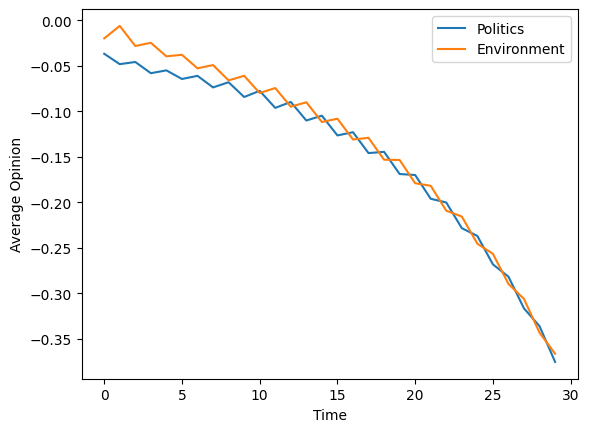

In [ ]:
avg_politics = []
avg_environment = []

for step in history:
    avg_politics.append(np.mean([step[i]["politics"] for i in step]))
    
    avg_environment.append(np.mean([step[i]["environment"] for i in step]))

plt.plot(avg_politics, label="Politics")
plt.plot(avg_environment, label="Environment")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Average Opinion")
plt.show()


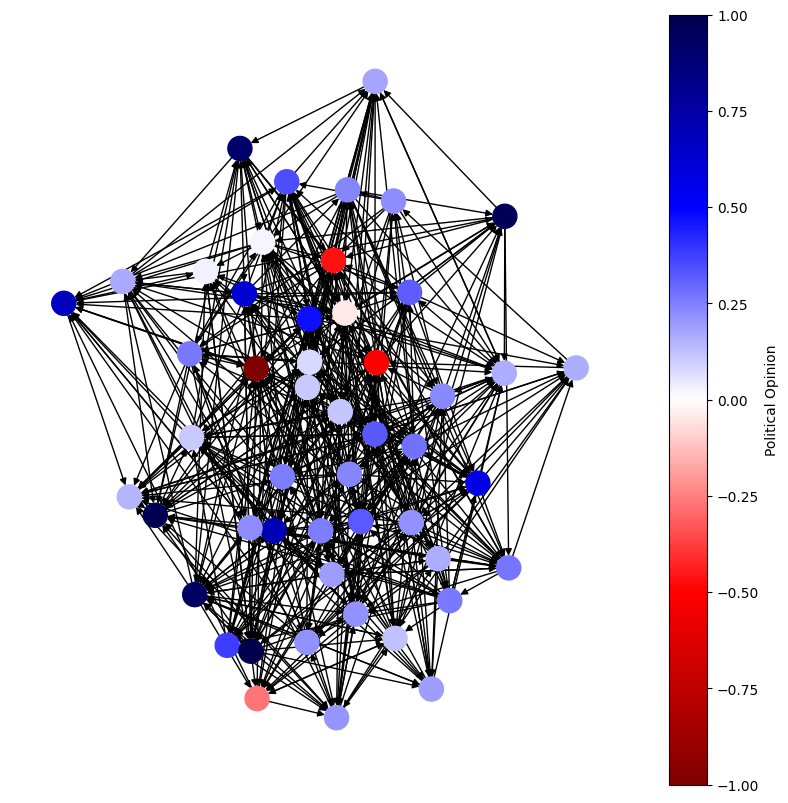

In [33]:
final_opinions = history[-1]
node_colors = [final_opinions[i]["politics"] for i in G.nodes]

fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos, 
    node_color=node_colors,
    cmap=plt.cm.seismic_r,
    node_size=300
    )

norm = plr.Normalize(vmin=-1, vmax=1)
sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.seismic_r)
sm.set_array([])  # required dummy array

fig.colorbar(sm, ax=ax, label="Political Opinion")

plt.show()